# Notebook 4: Regression Analysis
**Course:** Economic and Social Statistics (AST3336) — Year 3, Semester 2
**Institution:** University of Rwanda, College of Business and Economics
**Group:** Group 1 — AHS 2024: Poverty & Demographics

---

## Objective
Estimate regression models to identify demographic and livelihood characteristics associated with poverty:

1. **Logit Model** — Binary poverty status (`poor`) as dependent variable
2. **Probit Model** — Same specification, alternative estimator
3. **Marginal Effects** — Average marginal effects for both models
4. **OLS Baseline Model** — Welfare quintile (`welfare_quintile`) as dependent variable
5. **Model comparison & interpretation**

### Model Specification
$$poor_i = f(head\_sex_i,\ head\_age_i,\ head\_age\_sq_i,\ hh\_size_i,\ dep\_ratio_i,\ livelihood\_ag_i,\ land\_ha\_log_i,\ d\_south_i,\ d\_west_i,\ d\_north_i,\ d\_east_i)$$

**Input:** `data/ahs2024_analysis.csv`
**Output:** Tables → `output/tables/`, Figures → `output/figures/`

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import Logit, Probit
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH   = r'..\data\ahs2024_analysis.csv'
TABLE_PATH  = r'..\output\tables'
FIGURE_PATH = r'..\output\figures'

df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]} households, {df.shape[1]} variables')
print(f'\nKey variables:')
print(df[['poor','welfare_quintile','head_sex','head_age','hh_size',
          'dep_ratio','livelihood_ag','land_ha_log']].describe().round(3))

Dataset loaded: 3724 households, 31 variables

Key variables:
           poor  welfare_quintile  head_sex  head_age   hh_size  dep_ratio  \
count 3724.0000         3724.0000 3724.0000 3721.0000 3724.0000  3467.0000   
mean     0.2390            2.9600    0.7340   49.5490    4.3750     0.8880   
std      0.4260            1.2760    0.4420   15.6110    1.9520     0.7620   
min      0.0000            1.0000    0.0000   19.0000    1.0000     0.0000   
25%      0.0000            2.0000    0.0000   37.0000    3.0000     0.4000   
50%      0.0000            3.0000    1.0000   47.0000    4.0000     0.7500   
75%      0.0000            4.0000    1.0000   62.0000    6.0000     1.0000   
max      1.0000            5.0000    1.0000   97.0000   14.0000     6.0000   

       livelihood_ag  land_ha_log  
count      3724.0000    3717.0000  
mean          1.0000      -1.2820  
std           0.0000       0.9410  
min           1.0000      -4.6040  
25%           1.0000      -1.8740  
50%           1.000

## 2. Prepare Regression Dataset

In [2]:
# Define regressors
regressors = [
    'head_sex',      # Sex of HH head (1=Male, 0=Female)
    'head_age',      # Age of HH head
    'head_age_sq',   # Age squared (non-linear effect)
    'hh_size',       # Household size
    'dep_ratio',     # Dependency ratio
    'livelihood_ag', # Main livelihood (1=Agriculture)
    'land_ha_log',   # Log of agricultural land
    'd_south',       # Province dummies (Kigali = reference)
    'd_west',
    'd_north',
    'd_east'
]

# Dependent variables
dep_binary   = 'poor'
dep_ols      = 'welfare_quintile'

# Drop rows with missing values in any regression variable
reg_vars = [dep_binary, dep_ols] + regressors
df_reg = df[reg_vars].dropna().copy()

print(f'Full dataset:      {len(df)} households')
print(f'Regression sample: {len(df_reg)} households')
print(f'Dropped (missing): {len(df) - len(df_reg)} households')
print(f'\nPoverty rate in regression sample: {df_reg["poor"].mean()*100:.2f}%')

Full dataset:      3724 households
Regression sample: 3460 households
Dropped (missing): 264 households

Poverty rate in regression sample: 24.71%


In [3]:
# Prepare X and y matrices
X = df_reg[regressors].astype(float)
X_const = sm.add_constant(X)  # Add intercept
y_logit  = df_reg[dep_binary].astype(float)
y_ols    = df_reg[dep_ols].astype(float)

print('X matrix shape:', X_const.shape)
print('y (poor) shape:', y_logit.shape)
print('y (quintile) shape:', y_ols.shape)
print('\nCorrelation of regressors with poverty:')
print(X.corrwith(y_logit).round(4).sort_values())

X matrix shape: (3460, 11)
y (poor) shape: (3460,)
y (quintile) shape: (3460,)

Correlation of regressors with poverty:
land_ha_log     -0.1637
d_north         -0.0910
d_east          -0.0636
head_age_sq     -0.0027
head_sex        -0.0014
head_age         0.0071
dep_ratio        0.0346
d_south          0.0564
d_west           0.1015
hh_size          0.1671
livelihood_ag       NaN
dtype: float64


## 3. Logit Model

In [4]:
# -------------------------------------------------------
# Estimate Logit Model
# -------------------------------------------------------
logit_model  = Logit(y_logit, X_const)
logit_result = logit_model.fit(maxiter=200, disp=True)

print(logit_result.summary2())

Optimization terminated successfully.
         Current function value: 0.509219
         Iterations 6
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: poor             Pseudo R-squared: 0.089     
Date:               2026-03-14 00:13 AIC:              3545.7932 
No. Observations:   3460             BIC:              3613.4325 
Df Model:           10               Log-Likelihood:   -1761.9   
Df Residuals:       3449             LL-Null:          -1934.6   
Converged:          1.0000           LLR p-value:      3.6991e-68
No. Iterations:     6.0000           Scale:            1.0000    
-----------------------------------------------------------------
                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------
head_sex         -0.1629   0.1104  -1.4756 0.1401 -0.3792  0.0535
head_age          0.0249   0.0203   1.2290 0.2191 -0.0148  0.0646


In [5]:
# Odds Ratios from Logit
logit_or = pd.DataFrame({
    'Coefficient'  : logit_result.params,
    'Odds Ratio'   : np.exp(logit_result.params),
    'Std. Error'   : logit_result.bse,
    'z-statistic'  : logit_result.tvalues,
    'p-value'      : logit_result.pvalues,
    'CI Lower (OR)': np.exp(logit_result.conf_int()[0]),
    'CI Upper (OR)': np.exp(logit_result.conf_int()[1])
}).round(4)

# Add significance stars
def stars(p):
    if p < 0.01:  return '***'
    elif p < 0.05: return '**'
    elif p < 0.1:  return '*'
    else:          return ''

logit_or['Sig.'] = logit_or['p-value'].apply(stars)

print('=== LOGIT MODEL — COEFFICIENTS & ODDS RATIOS ===')
print(logit_or.to_string())

logit_or.to_csv(os.path.join(TABLE_PATH, 'table7_logit_results.csv'))
print('\nLogit results saved ✓')

=== LOGIT MODEL — COEFFICIENTS & ODDS RATIOS ===
               Coefficient  Odds Ratio  Std. Error  z-statistic  p-value  CI Lower (OR)  CI Upper (OR) Sig.
head_sex           -0.1629      0.8497      0.1104      -1.4756   0.1401         0.6844         1.0549     
head_age            0.0249      1.0252      0.0203       1.2290   0.2191         0.9853         1.0668     
head_age_sq        -0.0002      0.9998      0.0002      -0.8252   0.4093         0.9995         1.0002     
hh_size             0.3160      1.3717      0.0271      11.6654   0.0000         1.3008         1.4465  ***
dep_ratio          -0.0940      0.9103      0.0580      -1.6199   0.1053         0.8125         1.0199     
livelihood_ag      -4.7704      0.0085      0.6951      -6.8634   0.0000         0.0022         0.0331  ***
land_ha_log        -0.6498      0.5222      0.0512     -12.6991   0.0000         0.4723         0.5772  ***
d_south             0.9050      2.4720      0.4653       1.9450   0.0518         0.9931

## 4. Probit Model

In [6]:
# -------------------------------------------------------
# Estimate Probit Model
# -------------------------------------------------------
probit_model  = Probit(y_logit, X_const)
probit_result = probit_model.fit(maxiter=200, disp=True)

print(probit_result.summary2())

Optimization terminated successfully.
         Current function value: 0.508581
         Iterations 6
                         Results: Probit
Model:              Probit           Method:           MLE       
Dependent Variable: poor             Pseudo R-squared: 0.090     
Date:               2026-03-14 00:13 AIC:              3541.3799 
No. Observations:   3460             BIC:              3609.0192 
Df Model:           10               Log-Likelihood:   -1759.7   
Df Residuals:       3449             LL-Null:          -1934.6   
Converged:          1.0000           LLR p-value:      4.2824e-69
No. Iterations:     6.0000           Scale:            1.0000    
-----------------------------------------------------------------
                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------
head_sex         -0.0939   0.0643  -1.4599 0.1443 -0.2199  0.0322
head_age          0.0149   0.0118   1.2660 0.2055 -0.0082  0.0380

In [7]:
# Probit coefficients table
probit_table = pd.DataFrame({
    'Coefficient': probit_result.params,
    'Std. Error' : probit_result.bse,
    'z-statistic': probit_result.tvalues,
    'p-value'    : probit_result.pvalues,
    'CI Lower'   : probit_result.conf_int()[0],
    'CI Upper'   : probit_result.conf_int()[1]
}).round(4)

probit_table['Sig.'] = probit_table['p-value'].apply(stars)

print('=== PROBIT MODEL — COEFFICIENTS ===')
print(probit_table.to_string())

probit_table.to_csv(os.path.join(TABLE_PATH, 'table8_probit_results.csv'))
print('\nProbit results saved ✓')

=== PROBIT MODEL — COEFFICIENTS ===
               Coefficient  Std. Error  z-statistic  p-value  CI Lower  CI Upper Sig.
head_sex           -0.0939      0.0643      -1.4599   0.1443   -0.2199    0.0322     
head_age            0.0149      0.0118       1.2660   0.2055   -0.0082    0.0380     
head_age_sq        -0.0001      0.0001      -0.8542   0.3930   -0.0003    0.0001     
hh_size             0.1885      0.0159      11.8708   0.0000    0.1574    0.2197  ***
dep_ratio          -0.0599      0.0340      -1.7611   0.0782   -0.1267    0.0068    *
livelihood_ag      -2.8185      0.3925      -7.1804   0.0000   -3.5879   -2.0492  ***
land_ha_log        -0.3877      0.0299     -12.9537   0.0000   -0.4463   -0.3290  ***
d_south             0.5011      0.2542       1.9711   0.0487    0.0028    0.9993   **
d_west              0.5483      0.2550       2.1499   0.0316    0.0484    1.0481   **
d_north             0.0327      0.2573       0.1271   0.8988   -0.4715    0.5370     
d_east            

## 5. Marginal Effects

In [8]:
# -------------------------------------------------------
# Average Marginal Effects — Logit
# -------------------------------------------------------
logit_me = logit_result.get_margeff(at='mean')
print('=== LOGIT — MARGINAL EFFECTS AT MEAN ===')
print(logit_me.summary())

=== LOGIT — MARGINAL EFFECTS AT MEAN ===
        Logit Marginal Effects       
Dep. Variable:                   poor
Method:                          dydx
At:                              mean
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
head_sex       -0.0282      0.019     -1.476      0.140      -0.066       0.009
head_age        0.0043      0.004      1.229      0.219      -0.003       0.011
head_age_sq  -2.75e-05   3.33e-05     -0.825      0.409   -9.28e-05    3.78e-05
hh_size         0.0547      0.005     11.872      0.000       0.046       0.064
dep_ratio      -0.0163      0.010     -1.620      0.105      -0.036       0.003
land_ha_log    -0.1125      0.009    -13.033      0.000      -0.129      -0.096
d_south         0.1567      0.080      1.948      0.051      -0.001       0.314
d_west          0.1693      0.081      2.099      0.036       0.011       0.327
d_north

In [9]:
# -------------------------------------------------------
# Average Marginal Effects — Probit
# -------------------------------------------------------
probit_me = probit_result.get_margeff(at='mean')
print('=== PROBIT — MARGINAL EFFECTS AT MEAN ===')
print(probit_me.summary())

=== PROBIT — MARGINAL EFFECTS AT MEAN ===
       Probit Marginal Effects       
Dep. Variable:                   poor
Method:                          dydx
At:                              mean
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
head_sex       -0.0282      0.019     -1.460      0.144      -0.066       0.010
head_age        0.0045      0.004      1.266      0.205      -0.002       0.011
head_age_sq -2.876e-05   3.37e-05     -0.854      0.393   -9.47e-05    3.72e-05
hh_size         0.0567      0.005     11.954      0.000       0.047       0.066
dep_ratio      -0.0180      0.010     -1.762      0.078      -0.038       0.002
land_ha_log    -0.1166      0.009    -13.109      0.000      -0.134      -0.099
d_south         0.1507      0.076      1.972      0.049       0.001       0.300
d_west          0.1649      0.077      2.151      0.031       0.015       0.315
d_nort

In [10]:
# -------------------------------------------------------
# Combined marginal effects table (Logit vs Probit)
# -------------------------------------------------------
me_logit_df = pd.DataFrame({
    'Logit ME'    : logit_me.margeff,
    'Logit SE'    : logit_me.margeff_se,
    'Logit p-val' : logit_me.pvalues,
    'Logit Sig.'  : pd.Series(logit_me.pvalues).apply(stars).values
}, index=logit_me.summary_frame().index)

me_probit_df = pd.DataFrame({
    'Probit ME'   : probit_me.margeff,
    'Probit SE'   : probit_me.margeff_se,
    'Probit p-val': probit_me.pvalues,
    'Probit Sig.' : pd.Series(probit_me.pvalues).apply(stars).values
}, index=probit_me.summary_frame().index)

me_combined = pd.concat([me_logit_df, me_probit_df], axis=1).round(4)

print('=== COMBINED MARGINAL EFFECTS — LOGIT vs PROBIT ===')
print(me_combined.to_string())

me_combined.to_csv(os.path.join(TABLE_PATH, 'table9_marginal_effects.csv'))
print('\nMarginal effects saved ✓')

=== COMBINED MARGINAL EFFECTS — LOGIT vs PROBIT ===
             Logit ME  Logit SE  Logit p-val Logit Sig.  Probit ME  Probit SE  Probit p-val Probit Sig.
head_sex      -0.0282    0.0191       0.1400               -0.0282     0.0193        0.1443            
head_age       0.0043    0.0035       0.2189                0.0045     0.0035        0.2054            
head_age_sq   -0.0000    0.0000       0.4091               -0.0000     0.0000        0.3929            
hh_size        0.0547    0.0046       0.0000        ***     0.0567     0.0047        0.0000         ***
dep_ratio     -0.0163    0.0100       0.1052               -0.0180     0.0102        0.0781           *
land_ha_log   -0.1125    0.0086       0.0000        ***    -0.1166     0.0089        0.0000         ***
d_south        0.1567    0.0805       0.0515          *     0.1507     0.0764        0.0486          **
d_west         0.1693    0.0806       0.0358         **     0.1649     0.0767        0.0315          **
d_north     

## 6. OLS Baseline Model

In [11]:
# -------------------------------------------------------
# OLS Model — welfare quintile as dependent variable
# -------------------------------------------------------
ols_model  = sm.OLS(y_ols, X_const)
ols_result = ols_model.fit(cov_type='HC3')  # Robust standard errors

print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:       welfare_quintile   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     67.20
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          1.25e-125
Time:                        00:14:04   Log-Likelihood:                -5465.8
No. Observations:                3460   AIC:                         1.095e+04
Df Residuals:                    3449   BIC:                         1.102e+04
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
head_sex          0.0637      0.053      1.196

In [12]:
# OLS results table
ols_table = pd.DataFrame({
    'Coefficient': ols_result.params,
    'Std. Error' : ols_result.bse,
    't-statistic': ols_result.tvalues,
    'p-value'    : ols_result.pvalues,
    'CI Lower'   : ols_result.conf_int()[0],
    'CI Upper'   : ols_result.conf_int()[1]
}).round(4)

ols_table['Sig.'] = ols_table['p-value'].apply(stars)

print('=== OLS MODEL — WELFARE QUINTILE ===')
print(f'R-squared: {ols_result.rsquared:.4f}')
print(f'Adj. R-squared: {ols_result.rsquared_adj:.4f}')
print(f'F-statistic: {ols_result.fvalue:.4f} (p={ols_result.f_pvalue:.4f})')
print(f'Observations: {int(ols_result.nobs)}')
print()
print(ols_table.to_string())

ols_table.to_csv(os.path.join(TABLE_PATH, 'table10_ols_results.csv'))
print('\nOLS results saved ✓')

=== OLS MODEL — WELFARE QUINTILE ===
R-squared: 0.1497
Adj. R-squared: 0.1472
F-statistic: 67.2035 (p=0.0000)
Observations: 3460

               Coefficient  Std. Error  t-statistic  p-value  CI Lower  CI Upper Sig.
head_sex            0.0637      0.0532       1.1963   0.2316   -0.0407    0.1681     
head_age           -0.0202      0.0090      -2.2498   0.0245   -0.0378   -0.0026   **
head_age_sq         0.0001      0.0001       1.7158   0.0862   -0.0000    0.0003    *
hh_size            -0.1989      0.0134     -14.8371   0.0000   -0.2252   -0.1726  ***
dep_ratio           0.0056      0.0283       0.1987   0.8425   -0.0498    0.0610     
livelihood_ag       5.5040      0.3004      18.3192   0.0000    4.9151    6.0929  ***
land_ha_log         0.4101      0.0242      16.9678   0.0000    0.3628    0.4575  ***
d_south            -0.7741      0.1960      -3.9505   0.0001   -1.1582   -0.3901  ***
d_west             -0.7645      0.1974      -3.8720   0.0001   -1.1514   -0.3775  ***
d_north   

## 7. Model Fit Statistics

In [13]:
# -------------------------------------------------------
# Model fit comparison table
# -------------------------------------------------------
fit_stats = pd.DataFrame({
    'Model'         : ['Logit', 'Probit', 'OLS'],
    'Dep. Variable' : ['Poor (binary)', 'Poor (binary)', 'Welfare Quintile'],
    'N'             : [int(logit_result.nobs), int(probit_result.nobs), int(ols_result.nobs)],
    'Log-Likelihood': [round(logit_result.llf, 2), round(probit_result.llf, 2), round(ols_result.llf, 2)],
    'AIC'           : [round(logit_result.aic, 2), round(probit_result.aic, 2), round(ols_result.aic, 2)],
    'BIC'           : [round(logit_result.bic, 2), round(probit_result.bic, 2), round(ols_result.bic, 2)],
    'Pseudo/R²'     : [
        round(logit_result.prsquared, 4),
        round(probit_result.prsquared, 4),
        round(ols_result.rsquared, 4)
    ]
})

print('=== MODEL FIT STATISTICS ===')
print(fit_stats.to_string(index=False))

fit_stats.to_csv(os.path.join(TABLE_PATH, 'table11_model_fit.csv'), index=False)
print('\nModel fit table saved ✓')

=== MODEL FIT STATISTICS ===
 Model    Dep. Variable    N  Log-Likelihood        AIC        BIC  Pseudo/R²
 Logit    Poor (binary) 3460      -1761.9000  3545.7900  3613.4300     0.0893
Probit    Poor (binary) 3460      -1759.6900  3541.3800  3609.0200     0.0904
   OLS Welfare Quintile 3460      -5465.7900 10953.5800 11021.2200     0.1497

Model fit table saved ✓


## 8. Figures

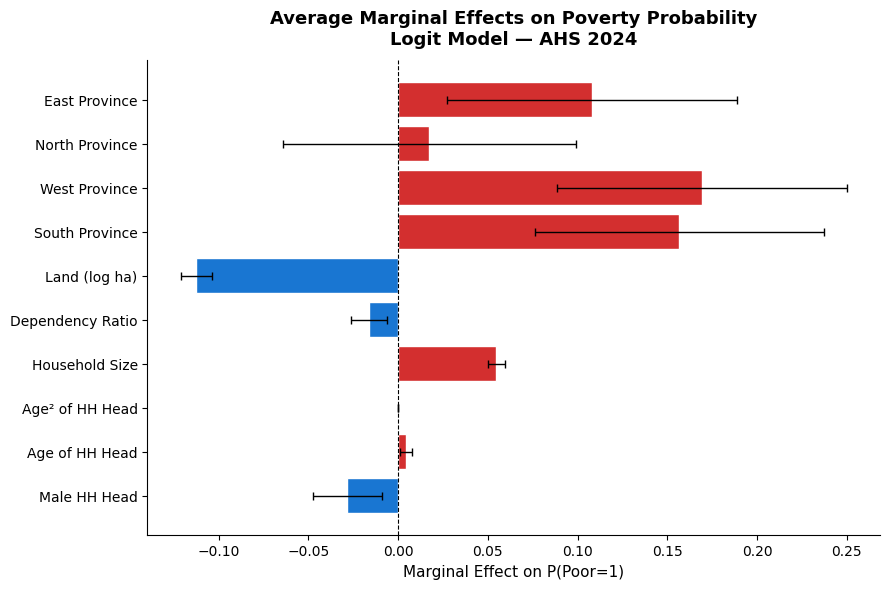

Figure 6 saved ✓


In [14]:
# -------------------------------------------------------
# Figure 6: Marginal effects plot (Logit)
# -------------------------------------------------------
me_df = logit_me.summary_frame().copy()
me_df = me_df.drop(index='const', errors='ignore')

# Variable labels for plot
var_labels = {
    'head_sex'     : 'Male HH Head',
    'head_age'     : 'Age of HH Head',
    'head_age_sq'  : 'Age² of HH Head',
    'hh_size'      : 'Household Size',
    'dep_ratio'    : 'Dependency Ratio',
    'livelihood_ag': 'Ag. Livelihood',
    'land_ha_log'  : 'Land (log ha)',
    'd_south'      : 'South Province',
    'd_west'       : 'West Province',
    'd_north'      : 'North Province',
    'd_east'       : 'East Province'
}
me_df.index = [var_labels.get(i, i) for i in me_df.index]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d32f2f' if v > 0 else '#1976d2' for v in me_df['dy/dx']]
bars = ax.barh(me_df.index, me_df['dy/dx'], color=colors,
               xerr=me_df['Std. Err.'], capsize=3,
               error_kw={'linewidth': 1}, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Average Marginal Effects on Poverty Probability\nLogit Model — AHS 2024',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Marginal Effect on P(Poor=1)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fig6_marginal_effects.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved ✓')

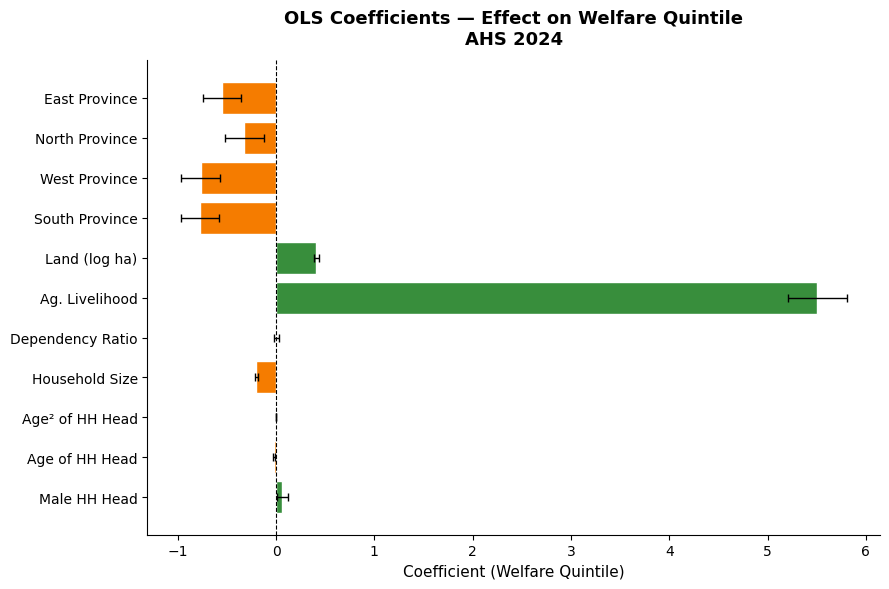

Figure 7 saved ✓


In [15]:
# -------------------------------------------------------
# Figure 7: OLS coefficients plot
# -------------------------------------------------------
ols_plot = ols_table.drop(index='const', errors='ignore').copy()
ols_plot.index = [var_labels.get(i, i) for i in ols_plot.index]

fig, ax = plt.subplots(figsize=(9, 6))
colors_ols = ['#388e3c' if v > 0 else '#f57c00' for v in ols_plot['Coefficient']]
ax.barh(ols_plot.index, ols_plot['Coefficient'],
        xerr=ols_plot['Std. Error'], capsize=3,
        color=colors_ols, edgecolor='white',
        error_kw={'linewidth': 1})
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('OLS Coefficients — Effect on Welfare Quintile\nAHS 2024',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Coefficient (Welfare Quintile)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fig7_ols_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved ✓')

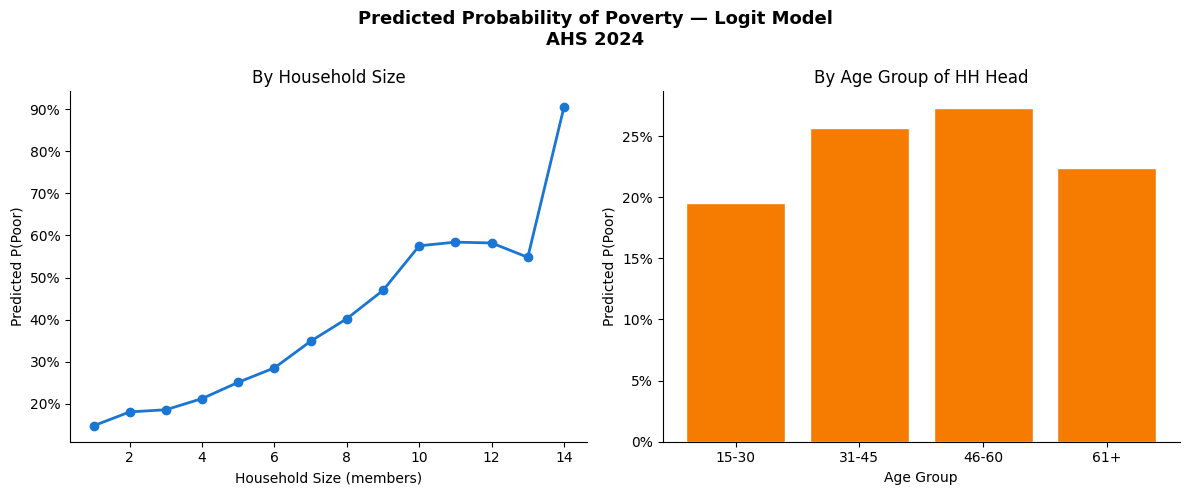

Figure 8 saved ✓


In [16]:
# -------------------------------------------------------
# Figure 8: Predicted probability of poverty by key variables
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Predicted Probability of Poverty — Logit Model\nAHS 2024',
             fontsize=13, fontweight='bold')

# Predicted probability by HH size
df_reg['pred_prob'] = logit_result.predict(X_const)
pred_size = df_reg.groupby('hh_size')['pred_prob'].mean()
axes[0].plot(pred_size.index, pred_size.values, 'o-', color='#1976d2', linewidth=2)
axes[0].set_title('By Household Size')
axes[0].set_xlabel('Household Size (members)')
axes[0].set_ylabel('Predicted P(Poor)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Predicted probability by age group
df['pred_prob_full'] = np.nan
df.loc[df_reg.index, 'pred_prob_full'] = logit_result.predict(X_const).values
df['head_age_group'] = pd.cut(
    df['head_age'], bins=[0,30,45,60,120],
    labels=['15-30','31-45','46-60','61+']
)
pred_age = df.groupby('head_age_group', observed=True)['pred_prob_full'].mean()
axes[1].bar(pred_age.index.astype(str), pred_age.values,
            color='#f57c00', edgecolor='white')
axes[1].set_title('By Age Group of HH Head')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Predicted P(Poor)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fig8_predicted_probabilities.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved ✓')

## 9. Interpretation Summary

In [17]:
# -------------------------------------------------------
# Print interpretation guide
# -------------------------------------------------------
print('=== INTERPRETATION GUIDE ===')
print()
print('--- LOGIT MODEL ---')
print('Coefficients: Log-odds of being poor')
print('Odds Ratios:  OR > 1 = increases odds of poverty')
print('              OR < 1 = decreases odds of poverty')
print()
print('--- PROBIT MODEL ---')
print('Coefficients: Change in z-score of poverty probability')
print('Sign same as Logit but magnitude smaller (~0.6x)')
print()
print('--- MARGINAL EFFECTS ---')
print('dy/dx: Change in P(poor=1) for unit change in X')
print('e.g. ME = -0.05 means variable reduces poverty probability by 5pp')
print()
print('--- OLS MODEL ---')
print('Coefficient: Change in welfare quintile for unit change in X')
print('Positive = improves welfare quintile (moves toward richest)')
print('Negative = worsens welfare quintile (moves toward poorest)')
print()

print('=== KEY SIGNIFICANT FINDINGS ===')
sig_logit = logit_or[logit_or['p-value'] < 0.05].drop(index='const', errors='ignore')
print('\nSignificant variables in Logit (p < 0.05):')
for var in sig_logit.index:
    coef = sig_logit.loc[var, 'Coefficient']
    OR   = sig_logit.loc[var, 'Odds Ratio']
    p    = sig_logit.loc[var, 'p-value']
    direction = 'INCREASES' if coef > 0 else 'DECREASES'
    print(f'  {var}: {direction} poverty odds (OR={OR:.3f}, p={p:.4f})')

sig_ols = ols_table[ols_table['p-value'] < 0.05].drop(index='const', errors='ignore')
print('\nSignificant variables in OLS (p < 0.05):')
for var in sig_ols.index:
    coef = sig_ols.loc[var, 'Coefficient']
    p    = sig_ols.loc[var, 'p-value']
    direction = 'IMPROVES' if coef > 0 else 'WORSENS'
    print(f'  {var}: {direction} welfare quintile (β={coef:.4f}, p={p:.4f})')

=== INTERPRETATION GUIDE ===

--- LOGIT MODEL ---
Coefficients: Log-odds of being poor
Odds Ratios:  OR > 1 = increases odds of poverty
              OR < 1 = decreases odds of poverty

--- PROBIT MODEL ---
Coefficients: Change in z-score of poverty probability
Sign same as Logit but magnitude smaller (~0.6x)

--- MARGINAL EFFECTS ---
dy/dx: Change in P(poor=1) for unit change in X
e.g. ME = -0.05 means variable reduces poverty probability by 5pp

--- OLS MODEL ---
Coefficient: Change in welfare quintile for unit change in X
Positive = improves welfare quintile (moves toward richest)
Negative = worsens welfare quintile (moves toward poorest)

=== KEY SIGNIFICANT FINDINGS ===

Significant variables in Logit (p < 0.05):
  hh_size: INCREASES poverty odds (OR=1.372, p=0.0000)
  livelihood_ag: DECREASES poverty odds (OR=0.009, p=0.0000)
  land_ha_log: DECREASES poverty odds (OR=0.522, p=0.0000)
  d_west: INCREASES poverty odds (OR=2.659, p=0.0360)

Significant variables in OLS (p < 0.05):
 

## 10. Final Output Summary

In [18]:
print('=== ALL REGRESSION OUTPUTS ===')
print('\nTABLES saved:')
for f in sorted(os.listdir(TABLE_PATH)):
    if f.endswith('.csv'):
        print(f'  ✓ {f}')

print('\nFIGURES saved:')
for f in sorted(os.listdir(FIGURE_PATH)):
    if f.endswith('.png'):
        print(f'  ✓ {f}')

print('\n✓ All 4 notebooks complete!')
print('✓ Ready to write Chapter 3 & Chapter 4 in LaTeX')

=== ALL REGRESSION OUTPUTS ===

TABLES saved:
  ✓ table10_ols_results.csv
  ✓ table11_model_fit.csv
  ✓ table1_summary_statistics.csv
  ✓ table2_by_province.csv
  ✓ table3_by_sex_of_head.csv
  ✓ table4_poverty_province_sex.csv
  ✓ table5_quintile_by_province.csv
  ✓ table6_ag_activity_poverty.csv
  ✓ table7_logit_results.csv
  ✓ table8_probit_results.csv
  ✓ table9_marginal_effects.csv

FIGURES saved:
  ✓ fig1_poverty_by_province.png
  ✓ fig2_poverty_by_sex.png
  ✓ fig3_quintile_by_province.png
  ✓ fig4_poverty_province_sex.png
  ✓ fig5_land_depratio_by_poverty.png
  ✓ fig6_marginal_effects.png
  ✓ fig7_ols_coefficients.png
  ✓ fig8_predicted_probabilities.png
  ✓ poverty_by_province_preview.png
  ✓ variable_distributions.png

✓ All 4 notebooks complete!
✓ Ready to write Chapter 3 & Chapter 4 in LaTeX


In [19]:
# -------------------------------------------------------
# Export results for report writing
# -------------------------------------------------------

print('='*60)
print('1. LOGIT ODDS RATIOS')
print('='*60)
print(logit_or.to_string())

print('\n' + '='*60)
print('2. MARGINAL EFFECTS')
print('='*60)
print(me_combined.to_string())

print('\n' + '='*60)
print('3. OLS RESULTS')
print('='*60)
print(ols_table.to_string())

print('\n' + '='*60)
print('4. MODEL FIT')
print('='*60)
print(fit_stats.to_string(index=False))

print('\n' + '='*60)
print('5. SIGNIFICANT VARIABLES - LOGIT')
print('='*60)
print(logit_or[logit_or['p-value'] < 0.05].to_string())

print('\n' + '='*60)
print('6. SIGNIFICANT VARIABLES - OLS')
print('='*60)
print(ols_table[ols_table['p-value'] < 0.05].to_string())

1. LOGIT ODDS RATIOS
               Coefficient  Odds Ratio  Std. Error  z-statistic  p-value  CI Lower (OR)  CI Upper (OR) Sig.
head_sex           -0.1629      0.8497      0.1104      -1.4756   0.1401         0.6844         1.0549     
head_age            0.0249      1.0252      0.0203       1.2290   0.2191         0.9853         1.0668     
head_age_sq        -0.0002      0.9998      0.0002      -0.8252   0.4093         0.9995         1.0002     
hh_size             0.3160      1.3717      0.0271      11.6654   0.0000         1.3008         1.4465  ***
dep_ratio          -0.0940      0.9103      0.0580      -1.6199   0.1053         0.8125         1.0199     
livelihood_ag      -4.7704      0.0085      0.6951      -6.8634   0.0000         0.0022         0.0331  ***
land_ha_log        -0.6498      0.5222      0.0512     -12.6991   0.0000         0.4723         0.5772  ***
d_south             0.9050      2.4720      0.4653       1.9450   0.0518         0.9931         6.1533    *
d_west 

## Summary of Models

| Model | DV | Estimator | Key Output |
|-------|----|-----------|------------|
| Logit | `poor` (binary) | Maximum Likelihood | Coefficients, Odds Ratios |
| Probit | `poor` (binary) | Maximum Likelihood | Coefficients |
| Marginal Effects | `poor` (binary) | At mean | dy/dx |
| OLS | `welfare_quintile` | OLS + HC3 SE | Coefficients, R² |

**Regressors (all models):**
- `head_sex` — sex of household head
- `head_age` + `head_age_sq` — age of head (with non-linear effect)
- `hh_size` — household size
- `dep_ratio` — dependency ratio
- `livelihood_ag` — main livelihood activity
- `land_ha_log` — log of agricultural land
- `d_south`, `d_west`, `d_north`, `d_east` — province dummies (Kigali = reference)

**Next:** Write Chapter 3 (Methodology) and Chapter 4 (Results & Discussion) in LaTeX